In [1]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
brats_images_folder = ROOT_DIR + "datasets/final_flair_dataset_small/brats_registered/"
brats_masks_folder = ROOT_DIR + "datasets/final_flair_dataset_small/brats_masks_registered/"

In [22]:
mask_files = sorted([f for f in os.listdir(brats_masks_folder) if f.endswith('.nii') or f.endswith('.nii.gz')])

for mask_file in mask_files:
    mask_path = os.path.join(brats_masks_folder, mask_file)
    mask = nib.load(mask_path).get_fdata()
    mid_slice = mask.shape[2] // 2
    mask_slice = mask[:, :, mid_slice]
    #print(np.unique(mask_slice, return_counts=True))
    non_zero_count = np.count_nonzero(mask_slice)
    if non_zero_count < 20:
        #print(np.unique(mask_slice, return_counts=True))
        print(f"{mask_file}")

BraTS-GLI-00000-000-seg.nii.gz
BraTS-GLI-00014-000-seg.nii.gz
BraTS-GLI-00014-001-seg.nii.gz
BraTS-GLI-00024-001-seg.nii.gz
BraTS-GLI-00036-000-seg.nii.gz
BraTS-GLI-00043-000-seg.nii.gz
BraTS-GLI-00045-000-seg.nii.gz
BraTS-GLI-00045-001-seg.nii.gz
BraTS-GLI-00048-001-seg.nii.gz
BraTS-GLI-00061-000-seg.nii.gz
BraTS-GLI-00061-001-seg.nii.gz
BraTS-GLI-00063-000-seg.nii.gz
BraTS-GLI-00102-000-seg.nii.gz
BraTS-GLI-00108-000-seg.nii.gz
BraTS-GLI-00113-000-seg.nii.gz
BraTS-GLI-00144-000-seg.nii.gz
BraTS-GLI-00148-000-seg.nii.gz
BraTS-GLI-00152-000-seg.nii.gz
BraTS-GLI-00155-000-seg.nii.gz
BraTS-GLI-00157-000-seg.nii.gz
BraTS-GLI-00162-000-seg.nii.gz
BraTS-GLI-00170-000-seg.nii.gz
BraTS-GLI-00171-000-seg.nii.gz
BraTS-GLI-00192-000-seg.nii.gz
BraTS-GLI-00193-000-seg.nii.gz
BraTS-GLI-00206-000-seg.nii.gz
BraTS-GLI-00209-000-seg.nii.gz
BraTS-GLI-00218-000-seg.nii.gz
BraTS-GLI-00222-000-seg.nii.gz
BraTS-GLI-00227-000-seg.nii.gz
BraTS-GLI-00228-000-seg.nii.gz
BraTS-GLI-00243-000-seg.nii.gz
BraTS-GL

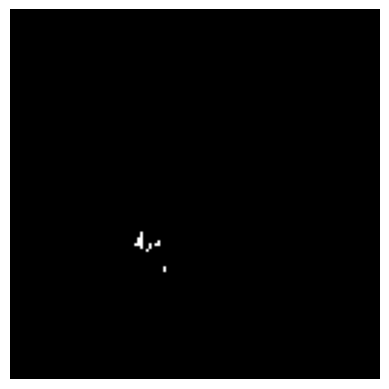

In [20]:
mask_path = os.path.join(brats_masks_folder, "BraTS-GLI-01007-000-seg.nii.gz")
mask = nib.load(mask_path).get_fdata()
mid_slice = mask.shape[2] // 2
mask_slice = mask[:, :, mid_slice]

plt.imshow(mask_slice, cmap='gray', origin='lower')
#plt.title("Middle Axial Slice: BraTS-GLI-01536-000-seg.nii.gz")
plt.axis('off')
plt.show()

In [ ]:
def display_middle_slices(images_folder, masks_folder, num_images=32):
    image_files = sorted([f for f in os.listdir(images_folder) if f.endswith('.nii') or f.endswith('.nii.gz')])[:num_images]
    mask_files = sorted([f for f in os.listdir(masks_folder) if f.endswith('.nii') or f.endswith('.nii.gz')])[:num_images]
    
    n_cols = 4
    n_rows = int(np.ceil(num_images / n_cols))
    plt.figure(figsize=(n_cols * 4, n_rows * 4))
    
    for i, (img_file, mask_file) in enumerate(zip(image_files, mask_files)):
        img_path = os.path.join(images_folder, img_file)
        mask_path = os.path.join(masks_folder, mask_file)
        
        img = nib.load(img_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()
        
        mid_slice = img.shape[2] // 2
        img_slice = img[:, :, mid_slice]
        mask_slice = mask[:, :, mid_slice]
        
        # Display image
        plt.subplot(n_rows, n_cols * 2, i * 2 + 1)
        plt.imshow(img_slice.T, cmap='gray', origin='lower')
        plt.title(f'Image: {img_file}')
        plt.axis('off')
        
        # Display mask
        plt.subplot(n_rows, n_cols * 2, i * 2 + 2)
        plt.imshow(mask_slice.T, cmap='Reds', alpha=0.5, origin='lower')
        plt.title(f'Mask: {mask_file}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage:
display_middle_slices(brats_images_folder, brats_masks_folder, num_images=32)